# 트리모델(Tree Machine Learning)

- 의사결정나무 (Decision Tree)
- 랜덤 포레스트 (Random Forest) ---> 앙상블(Ensemble)
- 그래디언트 부스트 (Gradient Boost)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 200

# 모델 평가를 위한 리스트
result = []

In [2]:
df = pd.read_csv('data/train_and_test2.csv')
df.head(3)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1


In [3]:
cols = df.columns[df.columns.str.contains('zero', case=False, na=False)]

df = df.drop(columns=['Passengerid'] + list(cols), errors='ignore')

df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [4]:
df = df.rename(columns={'2urvived' : 'Survived'})
df.head(3)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1


In [5]:
df['Embarked'].nunique

<bound method IndexOpsMixin.nunique of 0       2.0
1       0.0
2       2.0
3       2.0
4       2.0
       ... 
1304    2.0
1305    0.0
1306    2.0
1307    2.0
1308    0.0
Name: Embarked, Length: 1309, dtype: float64>

In [6]:
# 결측치 삭제하기
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1307 non-null   float64
 1   Fare      1307 non-null   float64
 2   Sex       1307 non-null   int64  
 3   sibsp     1307 non-null   int64  
 4   Parch     1307 non-null   int64  
 5   Pclass    1307 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1307 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 91.9 KB


In [7]:
X = df.drop(columns='Survived', axis=1)
y = df['Survived']

print(X.shape)
print(y.shape)

(1307, 7)
(1307,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1045, 7)
(262, 7)
(1045,)
(262,)


In [9]:
from sklearn.tree import DecisionTreeClassifier

# 모델 생성
dtc = DecisionTreeClassifier(random_state=42)
model = dtc.fit(X_train, y_train)

In [10]:
# Model prediction
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f'모델명: {model_name}')

    print(f'Accuracy: {acc:.4f}')
    print()

    print(report)
    print()

    # Visualization via heatmap
    plt.figure(figsize=(4, 3))

    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['사망(0)', '생존(1)'], yticklabels=['사망(0)', '생존(1)'])

    plt.xlabel('예측값')
    plt.ylabel('실제값')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()
    
    return acc, report, cm

모델명: Decision Tree
Accuracy: 0.7786

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       192
           1       0.60      0.53      0.56        70

    accuracy                           0.78       262
   macro avg       0.72      0.70      0.71       262
weighted avg       0.77      0.78      0.77       262




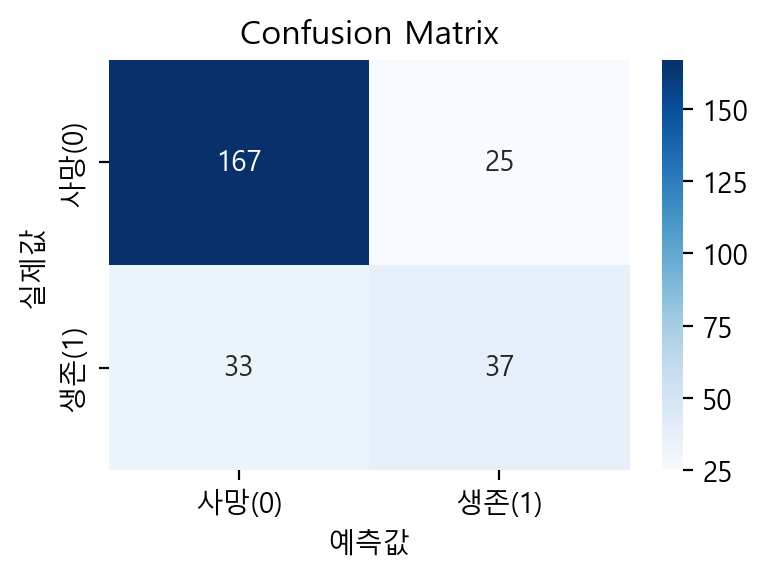

In [12]:
result.append(evaluate_model('Decision Tree', y_test, y_pred))

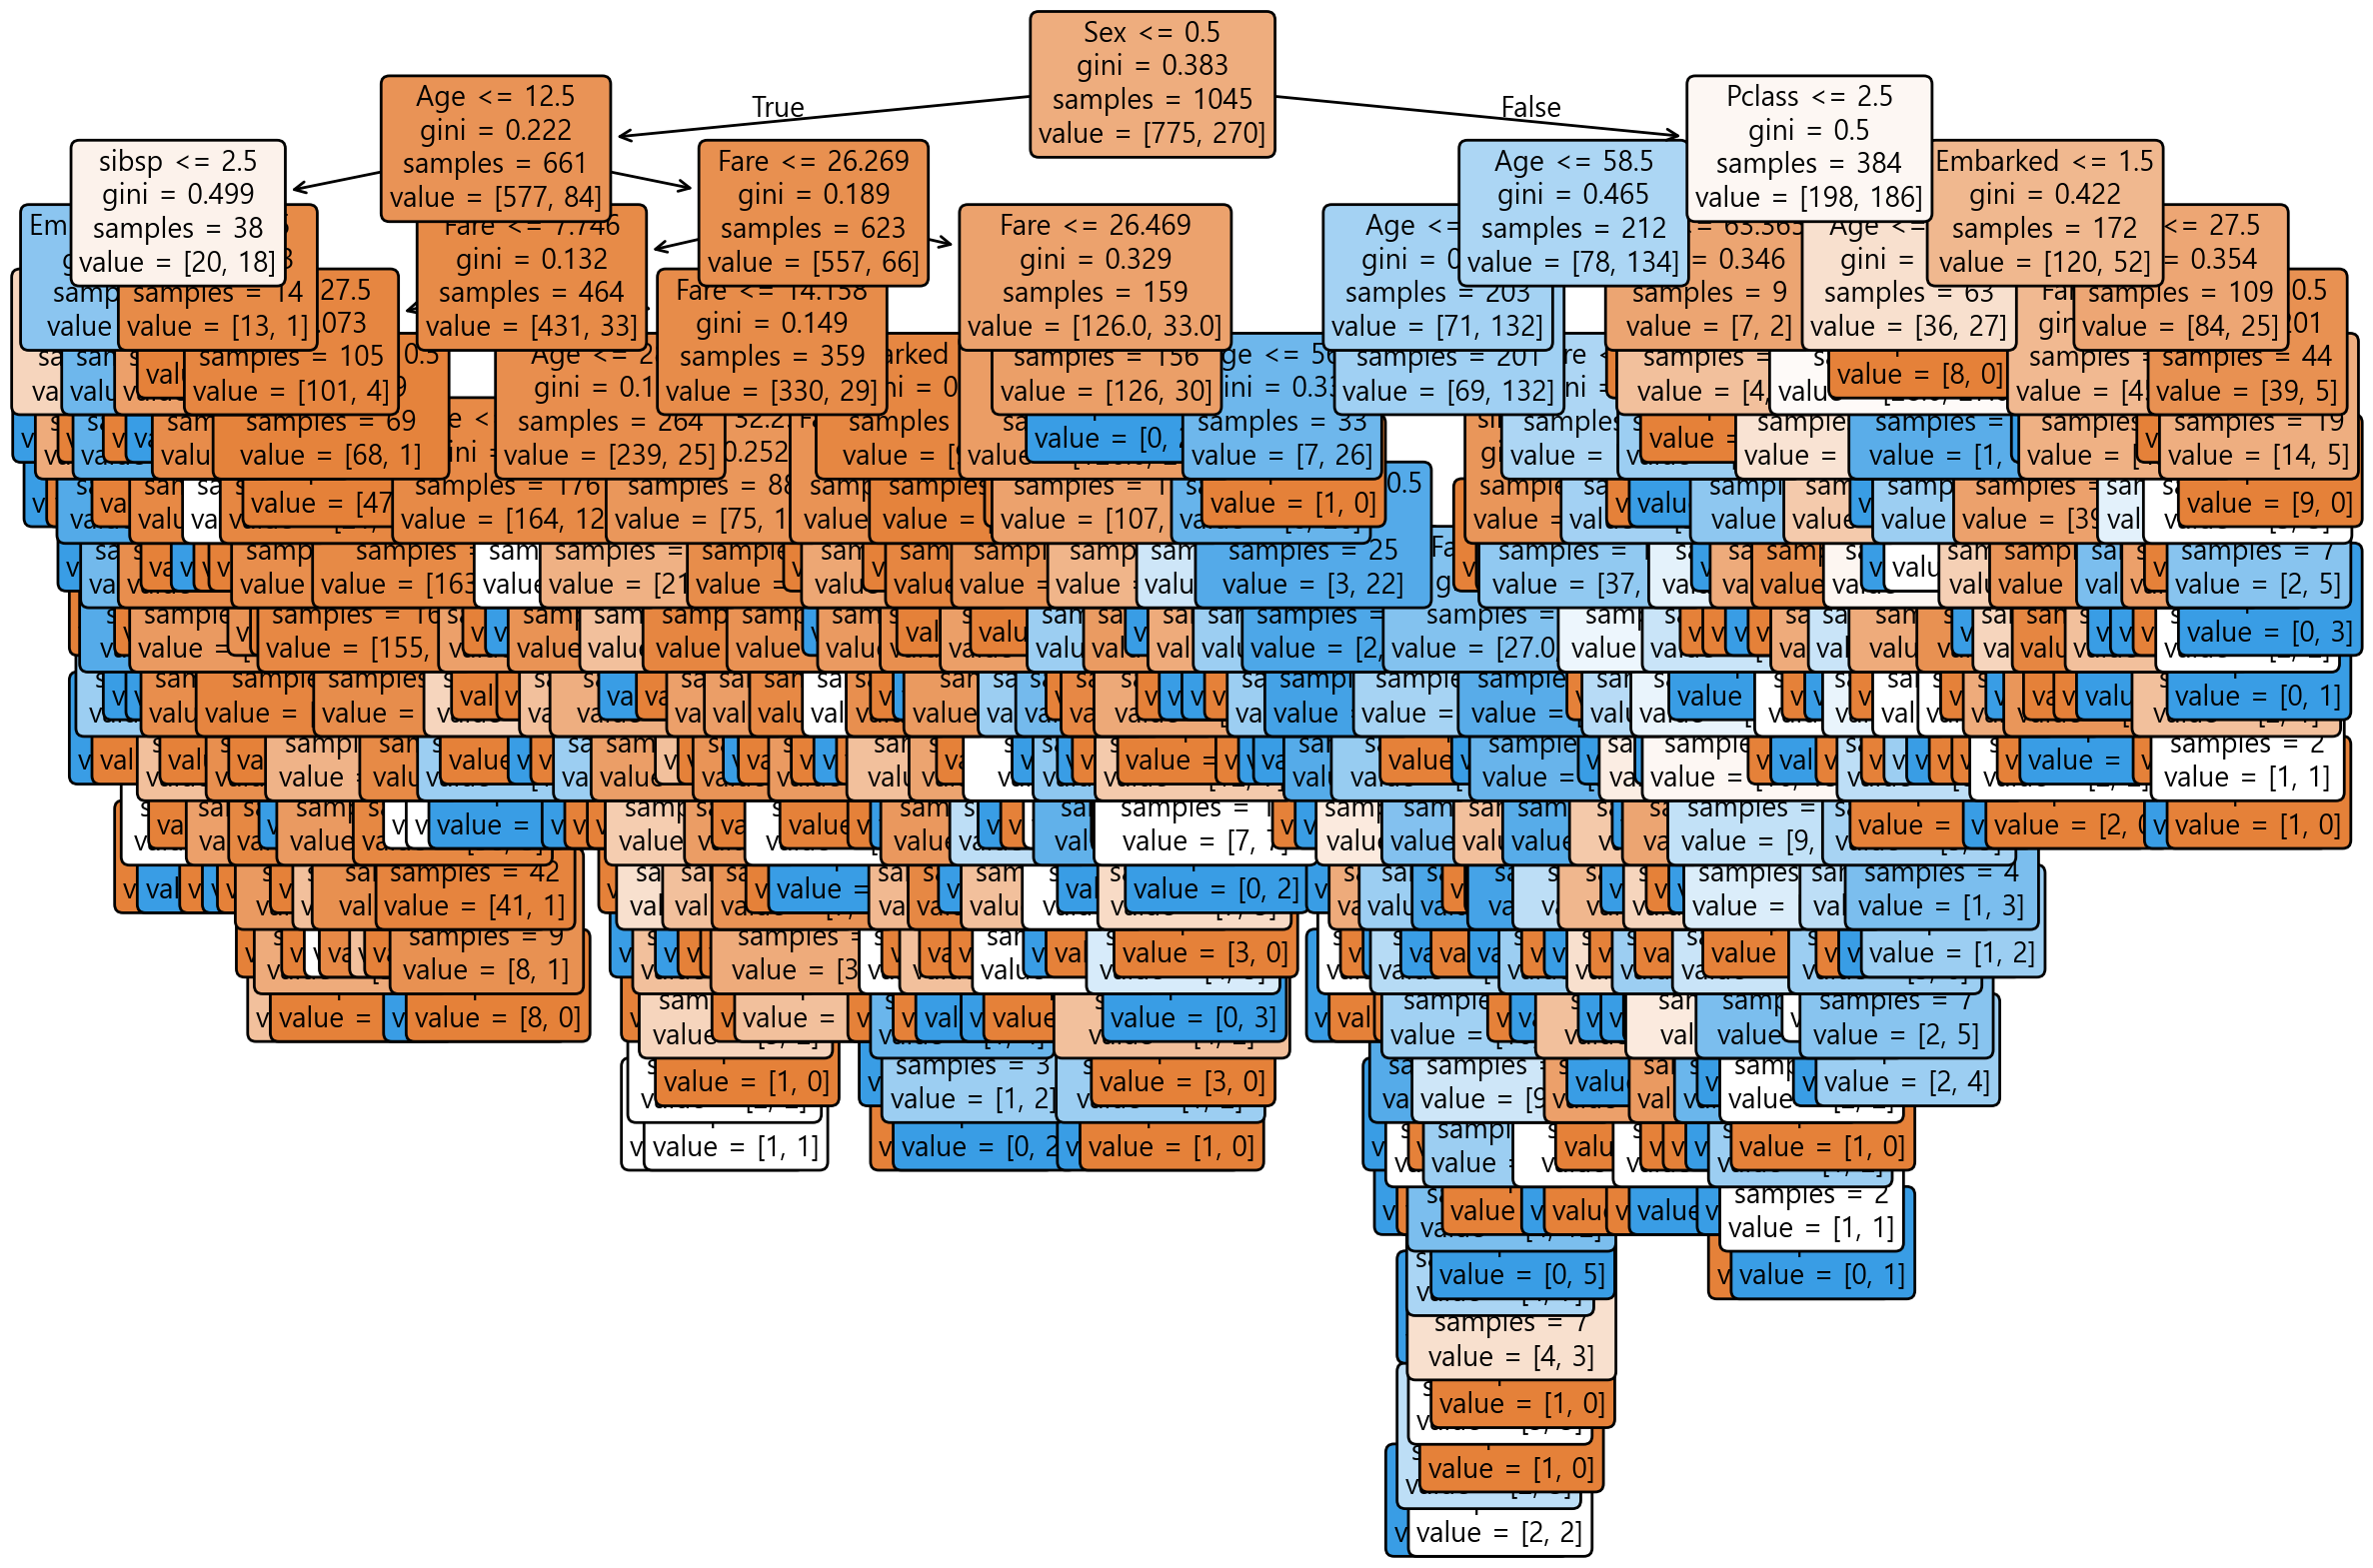

In [13]:
from sklearn.tree import plot_tree

feature_names = X_test.columns.values

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, rounded=True, fontsize=10, impurity=True, proportion=False, feature_names=feature_names)

plt.tight_layout()
plt.show()

# 과적합: 모델이 답을 외워버리는 것임

In [14]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators: number of est

# 학습
model = rfc.fit(X_train, y_train)

y_pred = model.predict(X_test)


모델명: Random Forest
Accuracy: 0.7672

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       192
           1       0.58      0.46      0.51        70

    accuracy                           0.77       262
   macro avg       0.70      0.67      0.68       262
weighted avg       0.75      0.77      0.76       262




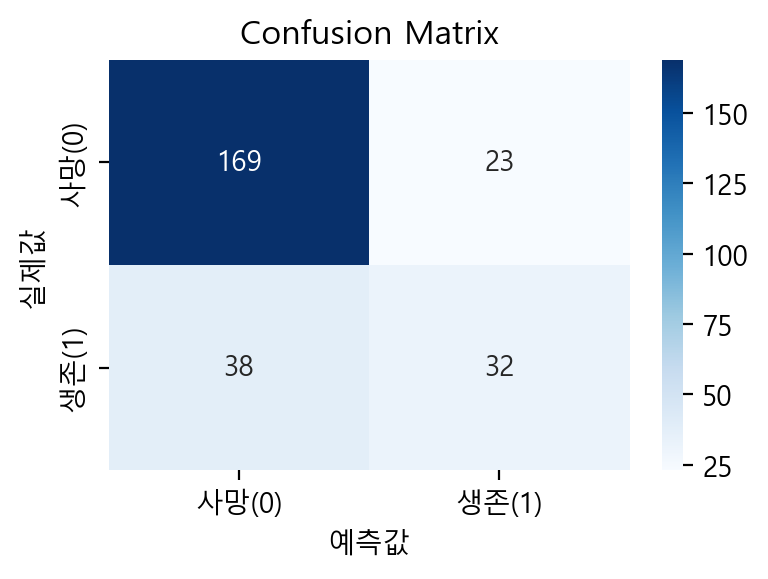

In [15]:
result.append(evaluate_model('Random Forest', y_test, y_pred))

In [16]:
# 그래디언트 부스팅

from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
model = gbc.fit(X_train, y_train)

y_pred = model.predict(X_test)

모델명: Gradient Boosting
Accuracy: 0.7786

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       192
           1       0.65      0.37      0.47        70

    accuracy                           0.78       262
   macro avg       0.73      0.65      0.67       262
weighted avg       0.76      0.78      0.76       262




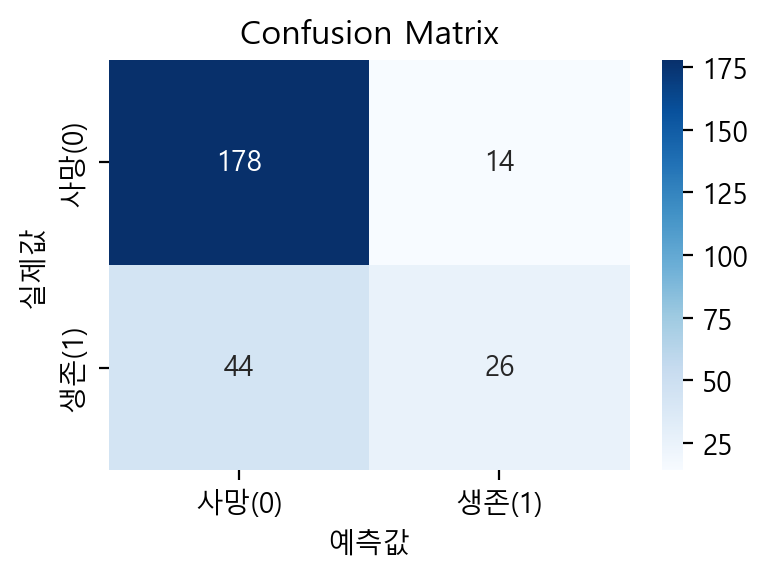

In [17]:
result.append(evaluate_model('Gradient Boosting', y_test, y_pred))

In [18]:
# Logistic 회귀도 테스트

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()   # 평균이 0, 표준편차가 1인 값들로 스케일링

X_train_s = scaler.fit_transform(X_train)   # 학습(다른 컬럼들과의 관계식)과 변환 둘 다 해줌
X_test_s = scaler.transform(X_test)         # 변환만 해줌

# 로지스틱 회귀 모델 생성과 학습
logiReg = LogisticRegression(random_state=42)
model = logiReg.fit(X_train_s, y_train)

# 예측하기
y_pred = model.predict(X_test_s)

모델명: Logistic Regression
Accuracy: 0.7901

              precision    recall  f1-score   support

           0       0.80      0.95      0.87       192
           1       0.73      0.34      0.47        70

    accuracy                           0.79       262
   macro avg       0.76      0.65      0.67       262
weighted avg       0.78      0.79      0.76       262




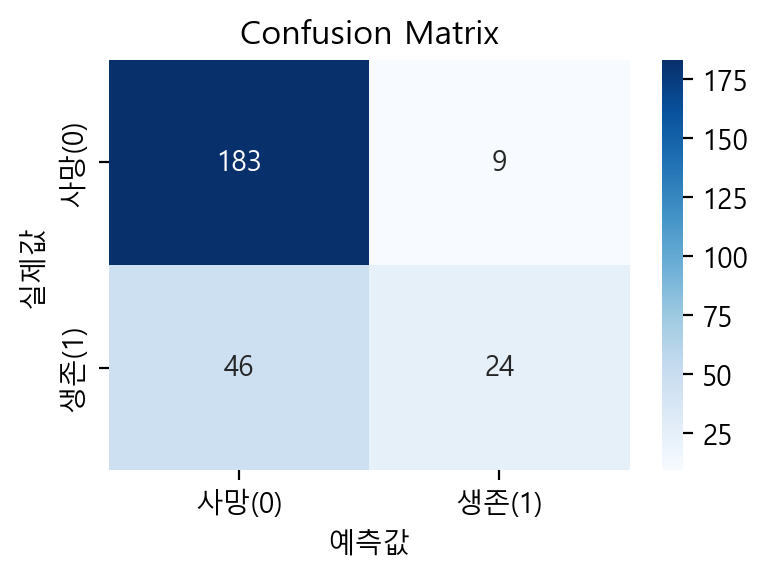

In [19]:
result.append(evaluate_model('Logistic Regression', y_test, y_pred))

In [20]:
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'Logistic Regression']

print('Accuracy Score')
for name, res in zip(models, result):
    print(f'{name}: {res[0]:.4f}')
    
df_result = pd.DataFrame(result, columns=['Accuracy', 'cr', 'cm'], index=models)
df_result = df_result.drop(columns=['cr', 'cm'])
df_result = df_result.sort_values('Accuracy', ascending=False)

Accuracy Score
Decision Tree: 0.7786
Random Forest: 0.7672
Gradient Boosting: 0.7786
Logistic Regression: 0.7901


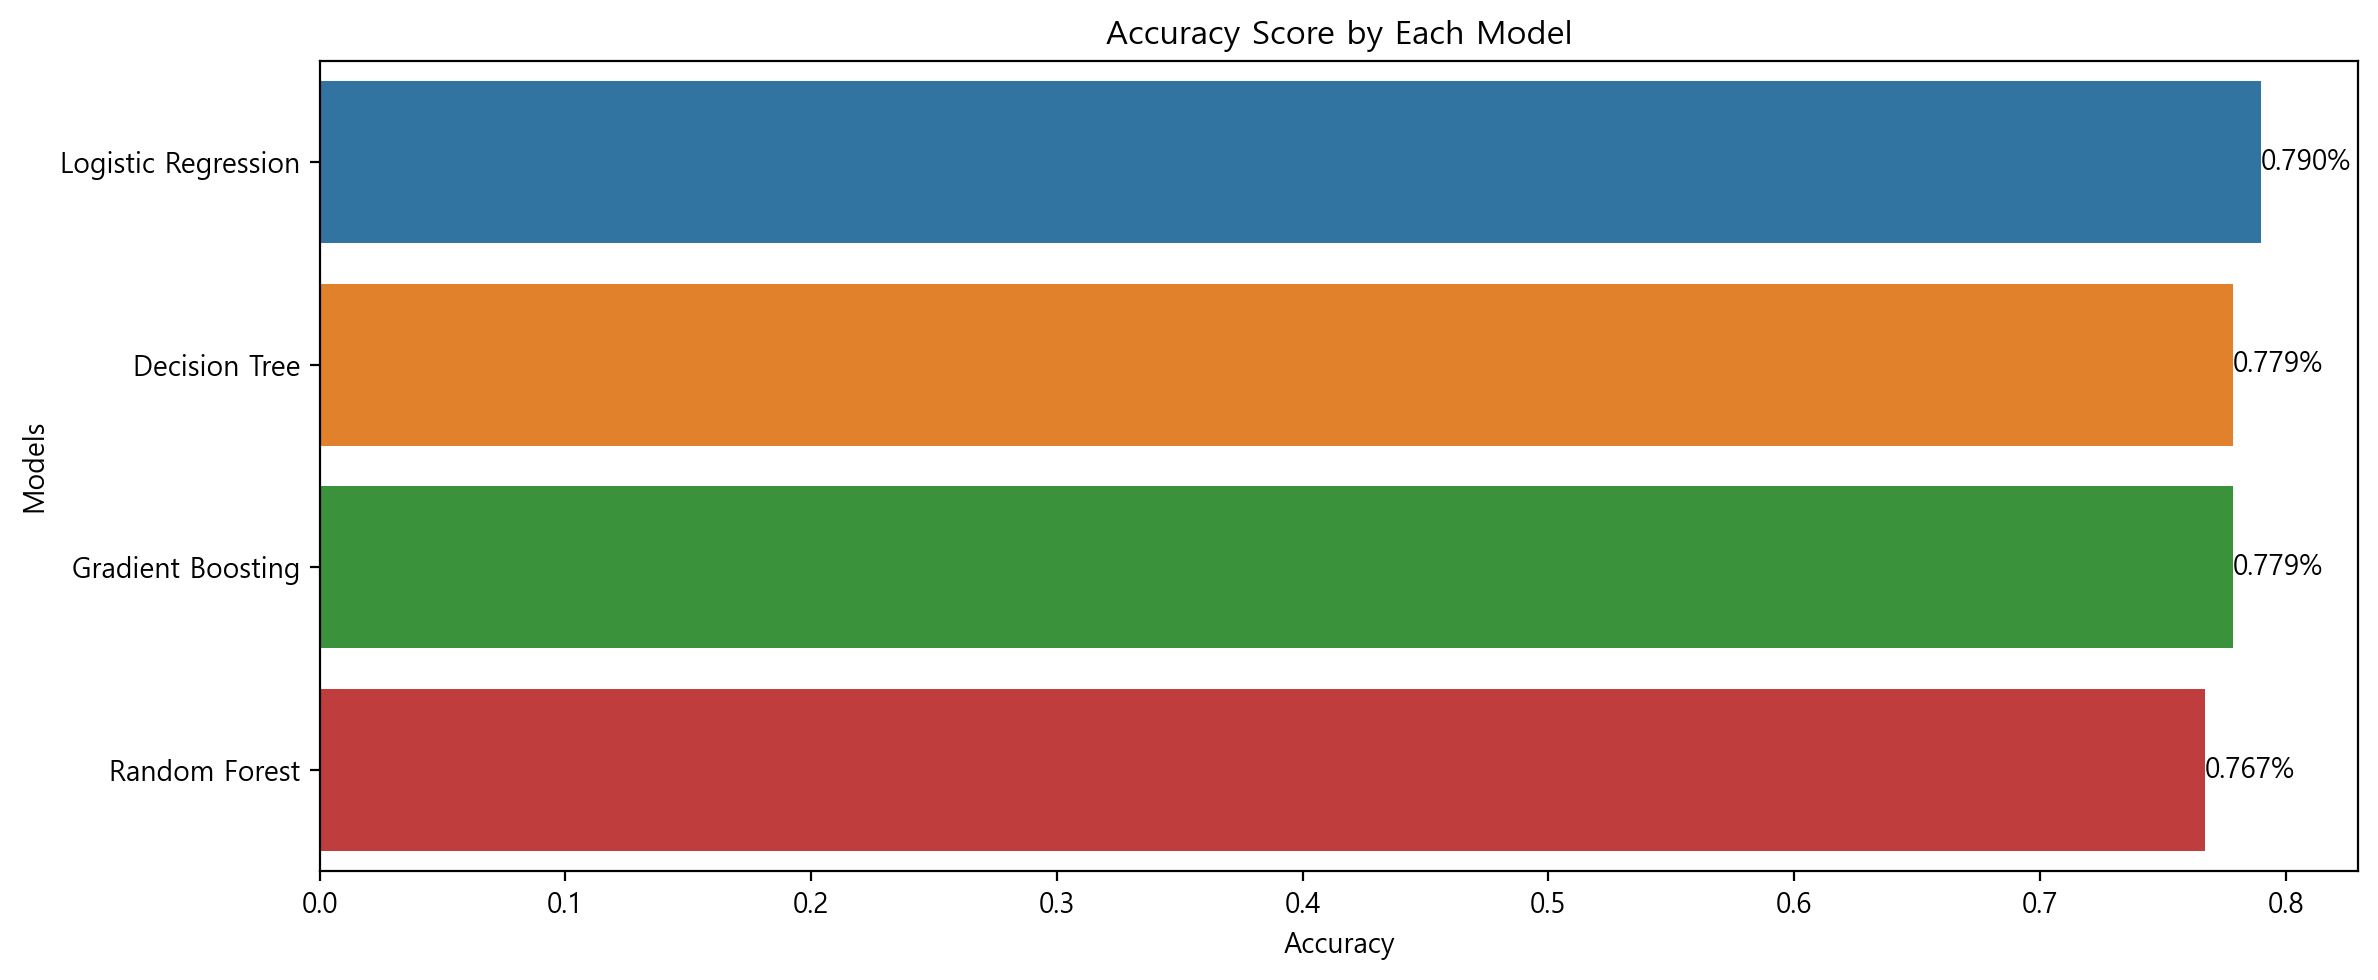

In [21]:
# 정확도 시각화하기
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=df_result, x='Accuracy', y=df_result.index, hue=df_result.index)
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.3f%%')
plt.title('Accuracy Score by Each Model')
plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.tight_layout()
plt.show()

최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
최적 cv 점수: 0.7914
모델명: Decision Tree(Tunned)
Accuracy: 0.8015

              precision    recall  f1-score   support

           0       0.82      0.93      0.87       192
           1       0.70      0.44      0.54        70

    accuracy                           0.80       262
   macro avg       0.76      0.69      0.71       262
weighted avg       0.79      0.80      0.79       262




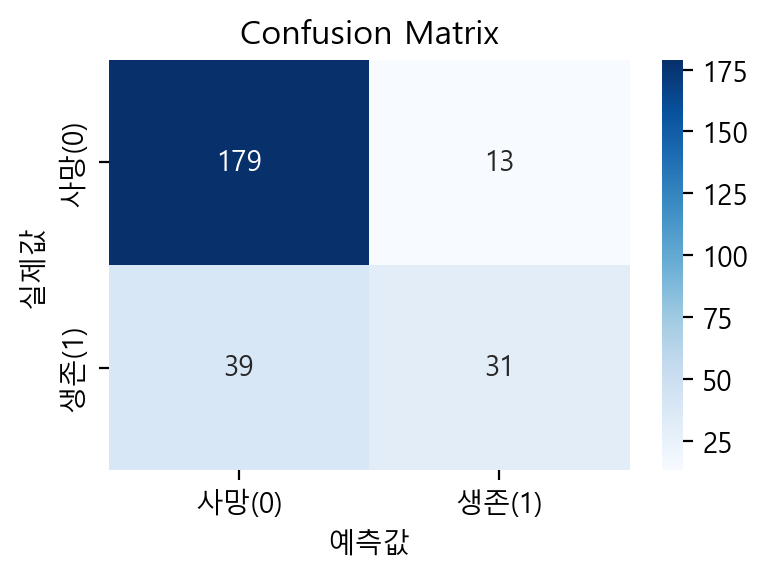

In [23]:
# 트리 모델 성능 개선(Hyper Parameter Tunning)

from sklearn.model_selection import GridSearchCV

# Decision Tree Parameters 정의하기
dt_params = {
    'max_depth' : [3,5,7,10,None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

# 정의하기
dt_grid_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1 # cv는 분할 수    
)

dt_grid_cv.fit(X_train, y_train)

print(f'최적 파라미터: {dt_grid_cv.best_params_}')
print(f'최적 cv 점수: {dt_grid_cv.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred = dt_grid_cv.predict(X_test)
result.append(evaluate_model('Decision Tree(Tunned)', y_test, y_pred))

최적 파라미터: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
최적 cv 점수: 0.7876
모델명: Random Forest(Tunned)
Accuracy: 0.7901

              precision    recall  f1-score   support

           0       0.80      0.94      0.87       192
           1       0.70      0.37      0.49        70

    accuracy                           0.79       262
   macro avg       0.75      0.66      0.68       262
weighted avg       0.78      0.79      0.77       262




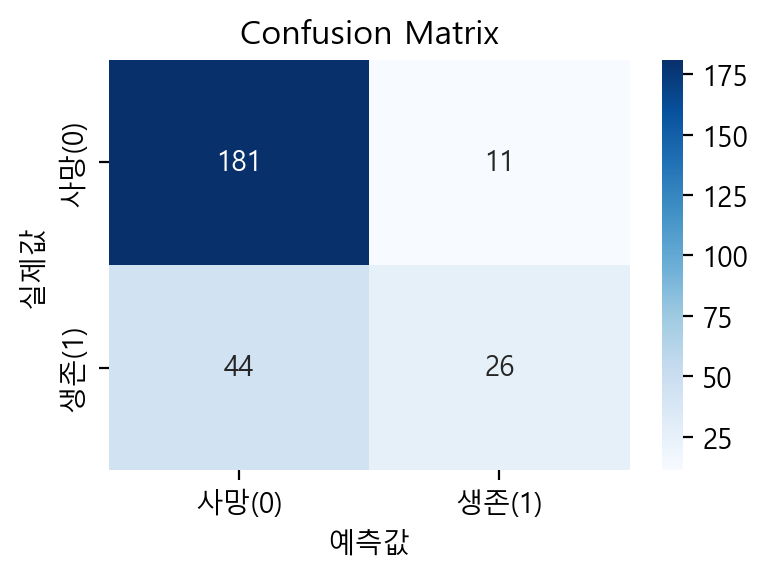

In [24]:
# Random Forest Parameters 정의하기
rf_params = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3,5,7,10,15,None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

# 정의하기
rf_grid_cv = GridSearchCV(
    RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1 # cv는 분할 수    
)

rf_grid_cv.fit(X_train, y_train)

print(f'최적 파라미터: {rf_grid_cv.best_params_}')
print(f'최적 cv 점수: {rf_grid_cv.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred = rf_grid_cv.predict(X_test)
result.append(evaluate_model('Random Forest(Tunned)', y_test, y_pred))

최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
최적 cv 점수: 0.7933
모델명: Random Forest(Tunned)
Accuracy: 0.7939

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       192
           1       0.69      0.41      0.52        70

    accuracy                           0.79       262
   macro avg       0.75      0.67      0.69       262
weighted avg       0.78      0.79      0.78       262




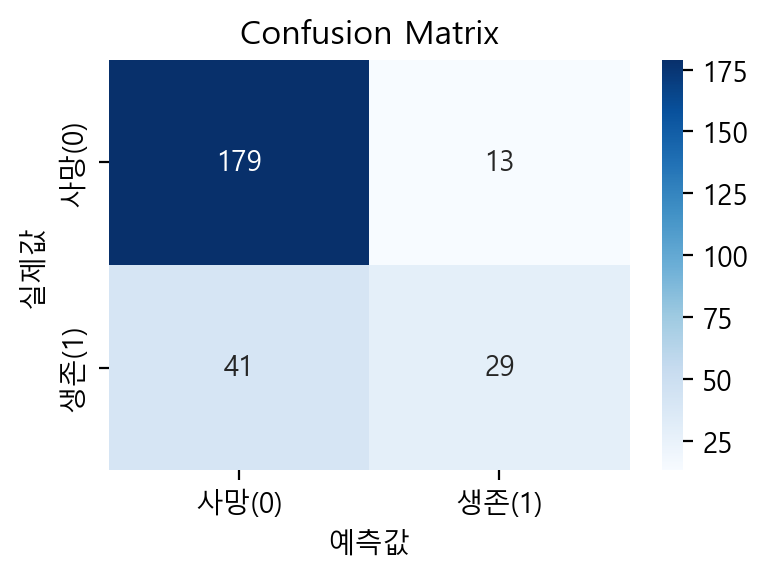

In [26]:
# Gradient Boosting Hyper Parameter Tunning

gb_params = {
    'n_estimators' : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'max_depth' : [3,5,7,10,15,None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

# 정의하기
gb_grid_cv = GridSearchCV(
    GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy', n_jobs=-1 # cv는 분할 수    
)

gb_grid_cv.fit(X_train, y_train)

print(f'최적 파라미터: {gb_grid_cv.best_params_}')
print(f'최적 cv 점수: {gb_grid_cv.best_score_:.4f}')

# 최적 모델로 테스트 평가
y_pred = gb_grid_cv.predict(X_test)
result.append(evaluate_model('Gradient Boosting(Tunned)', y_test, y_pred))

In [ ]:
models_ex = ['Decision Tree(Tunned)', 'Random Forest(Tunned)', 'Gradient Boosting(Tunned)']

models = models + models_ex
models

['Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'Logistic Regression',
 'Decision Tree(Tunned)',
 'Random Forest(Tunned)',
 'Gradient Boosting(Tunned)']

In [28]:
df_result2 = pd.DataFrame(result, columns=['Accuracy', 'cr', 'cf'], index=models)
df_result2 = df_result2.drop(columns=['cr', 'cf'])
df_result2 = df_result2.sort_values('Accuracy', ascending=False)
df_result2

,Accuracy
Decision Tree(Tunned),0.801527
Gradient Boosting(Tunned),0.793893
Logistic Regression,0.790076
Random Forest(Tunned),0.790076
Decision Tree,0.778626
Gradient Boosting,0.778626
Random Forest,0.767176


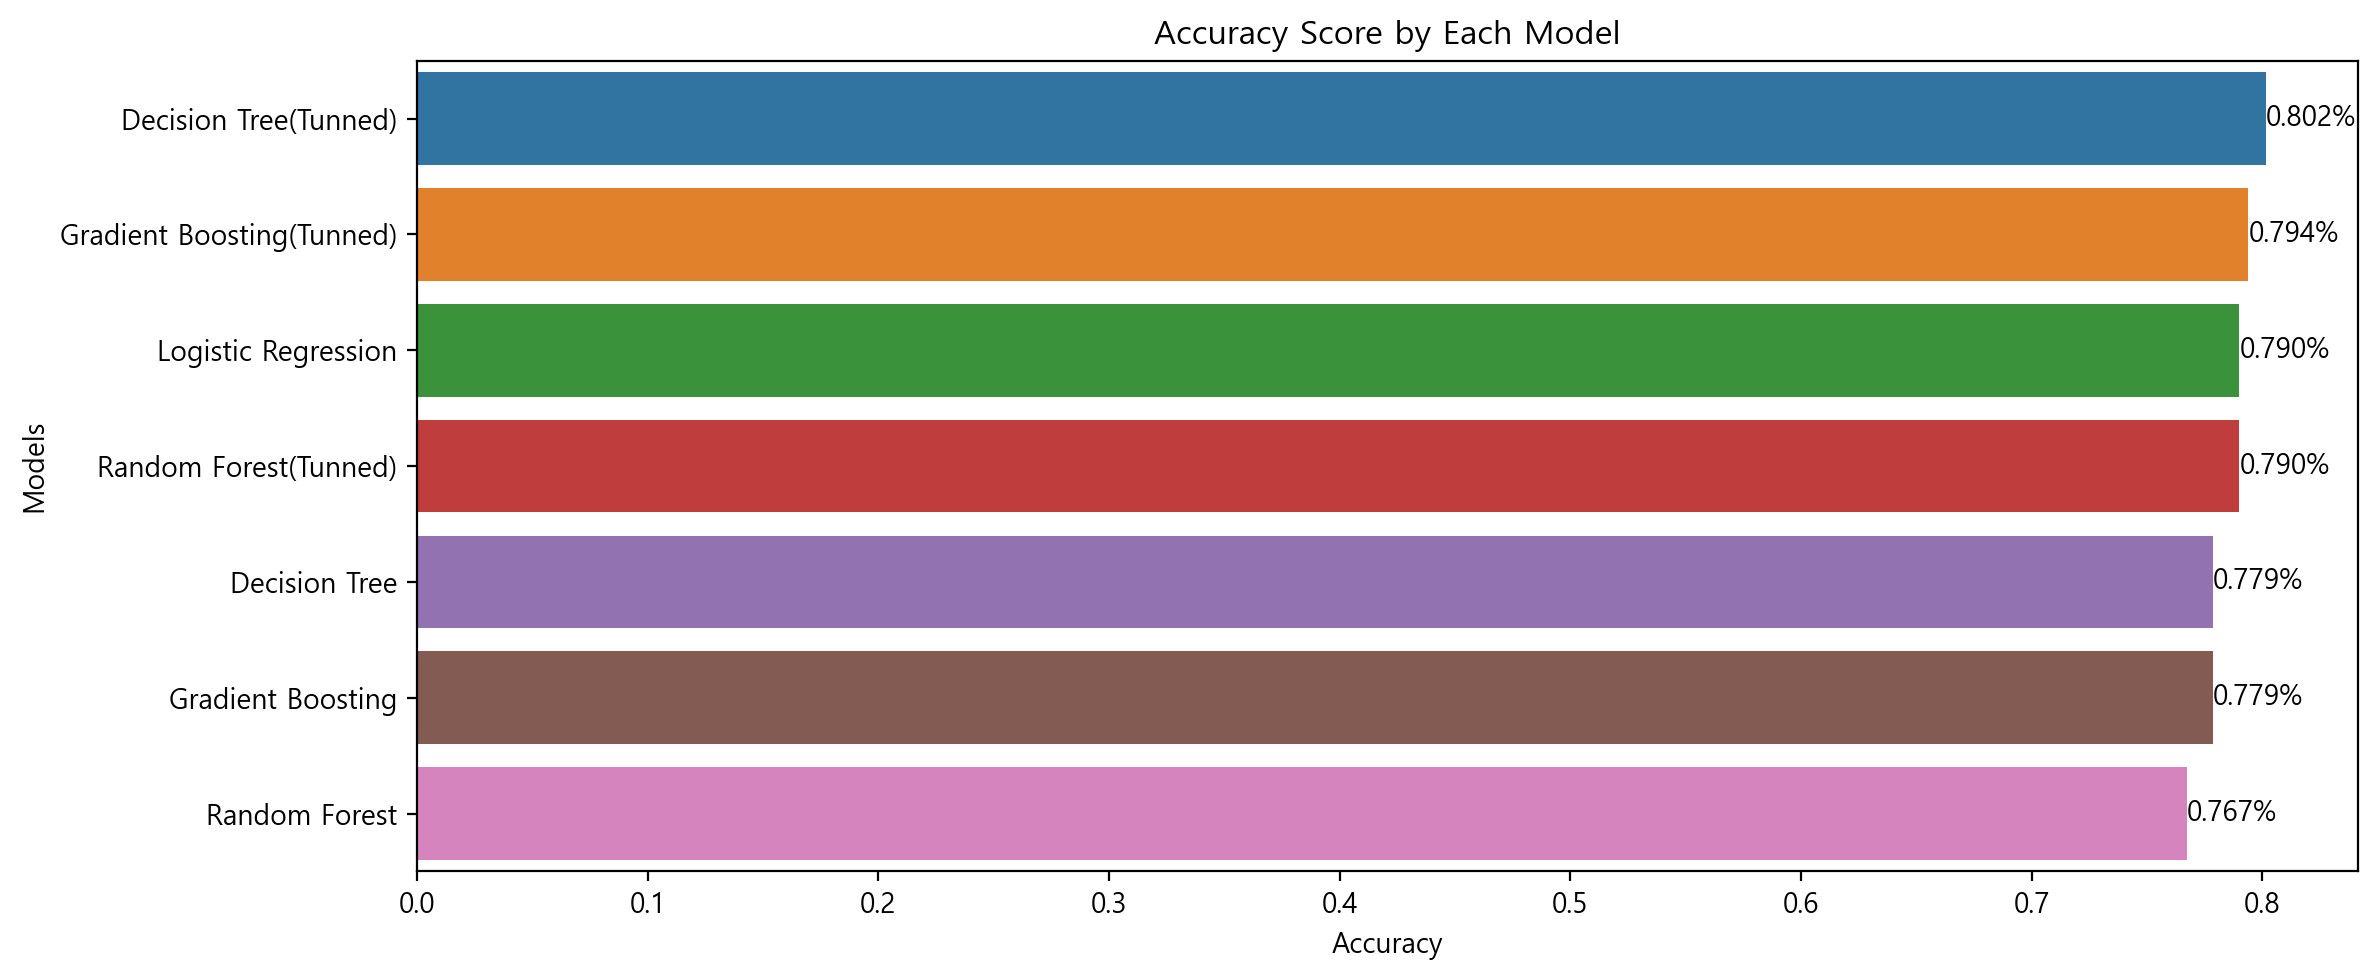

In [34]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=df_result2, x='Accuracy', y=df_result2.index, hue=df_result2.index)
for cont in ax.containers:
    plt.bar_label(cont, fmt='%.3f%%')
plt.title('Accuracy Score by Each Model')
plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.tight_layout()
plt.show()